In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [157]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'
arquivo = pd.read_csv(url)
arquivo.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [158]:
# Informações gerais sobre o dataset
print(arquivo.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [159]:
# Descrição estatística das variáveis numéricas
print(arquivo.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [160]:
print(arquivo['species'].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [161]:
arquivo['species'] = arquivo['species'].replace('setosa', 1)
arquivo['species'] = arquivo['species'].replace('versicolor', 2)
arquivo['species'] = arquivo['species'].replace('virginica', 3)

C:\Users\fabio\AppData\Local\Temp\ipykernel_18208\1591857262.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  arquivo['species'] = arquivo['species'].replace('virginica', 3)


In [162]:
# Método do Cotovelo (k-Elbow)
no_clusters=[]
j=[]

for i in range(1,10):
    model=KMeans(n_clusters=i, n_init=1)
    model.fit(arquivo)
    no_clusters.append(i)
    j.append(model.inertia_)

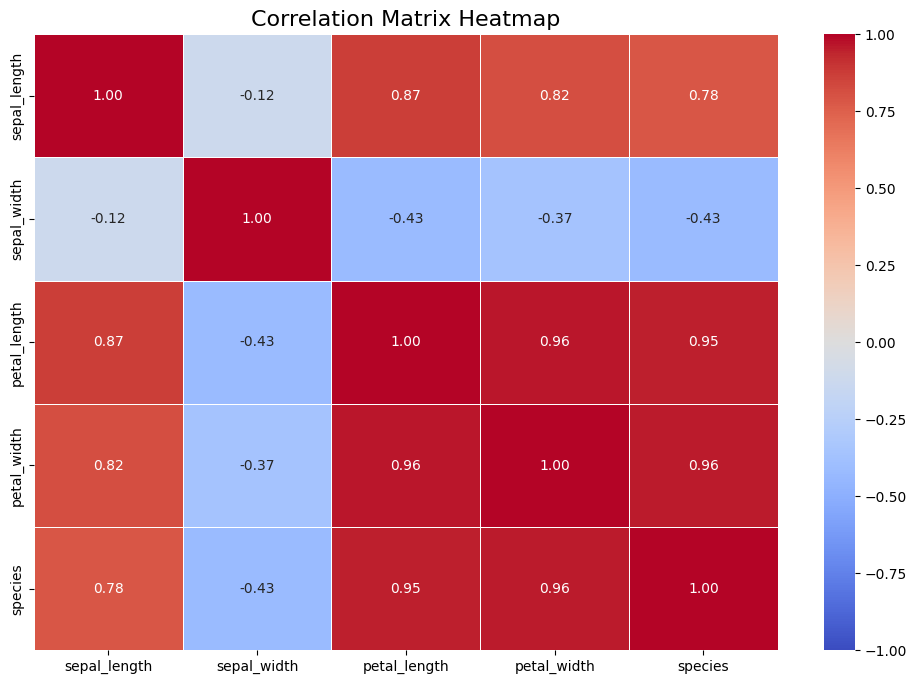

In [163]:
# As distribuições parecem melhores agora. Vamos exibir a nova matriz de correlação para análise.

correlation_matrix = arquivo.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin = -1)
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.show()

In [164]:
pd.DataFrame(no_clusters,j)

,0
781.370600,1
179.053583,2
87.220628,3
70.659449,4
51.171850,5
42.874793,6
35.648914,7
31.221010,8
32.121454,9


Text(0, 0.5, 'j')

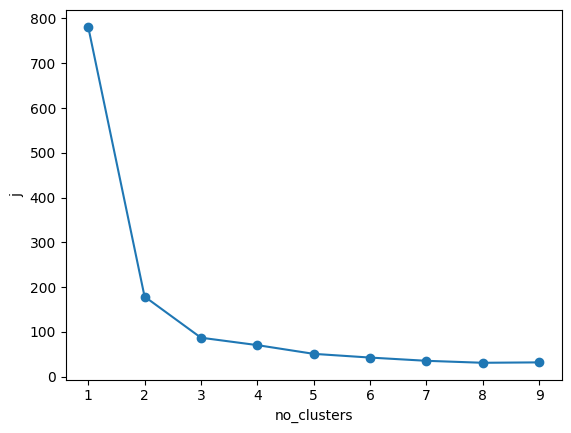

In [165]:
plt.plot(no_clusters,j,marker='o')
plt.xlabel('no_clusters')
plt.ylabel('j')

In [166]:
# Aplicando o K-means
model=KMeans(n_clusters=3, n_init=10)
model.fit(arquivo)
pre=model.predict(arquivo)

In [167]:
arquivo['KMeans']=pre

In [168]:
group1=arquivo[arquivo['KMeans']==0]
group2=arquivo[arquivo['KMeans']==1]
group3=arquivo[arquivo['KMeans']==2]

In [169]:
arquivo.head()

,sepal_length,sepal_width,petal_length,petal_width,species,KMeans
0,5.1,3.5,1.4,0.2,1,1
1,4.9,3.0,1.4,0.2,1,1
2,4.7,3.2,1.3,0.2,1,1
3,4.6,3.1,1.5,0.2,1,1
4,5.0,3.6,1.4,0.2,1,1


In [170]:
"""
plt.scatter(group1['sepal_length'],group1['sepal_width'],label='group1')
plt.scatter(group2['sepal_length'],group2['sepal_width'],label='group2')
plt.scatter(group3['sepal_length'],group3['sepal_width'],label='group3')
plt.legend()
plt.title('The cluster')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
"""

"\nplt.scatter(group1['sepal_length'],group1['sepal_width'],label='group1')\nplt.scatter(group2['sepal_length'],group2['sepal_width'],label='group2')\nplt.scatter(group3['sepal_length'],group3['sepal_width'],label='group3')\nplt.legend()\nplt.title('The cluster')\nplt.xlabel('Sepal Length')\nplt.ylabel('Sepal Width')\n"

In [171]:
"""
plt.scatter(group1['petal_length'],group1['petal_width'],label='group1')
plt.scatter(group2['petal_length'],group2['petal_width'],label='group2')
plt.scatter(group3['petal_length'],group3['petal_width'],label='group3')
plt.legend()
plt.title('The cluster')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
"""

"\nplt.scatter(group1['petal_length'],group1['petal_width'],label='group1')\nplt.scatter(group2['petal_length'],group2['petal_width'],label='group2')\nplt.scatter(group3['petal_length'],group3['petal_width'],label='group3')\nplt.legend()\nplt.title('The cluster')\nplt.xlabel('Sepal Length')\nplt.ylabel('Sepal Width')\n"

Text(0, 0.5, 'Sepal Width')

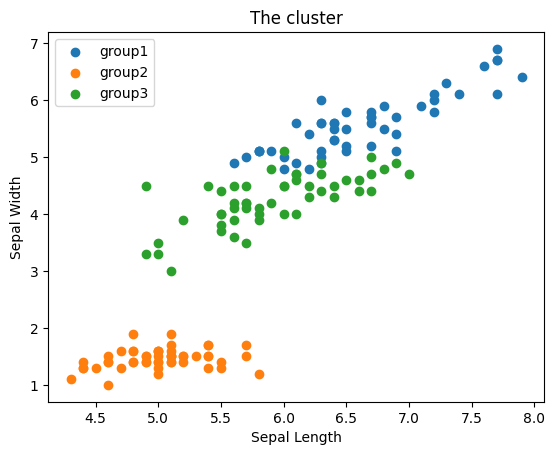

In [172]:
plt.scatter(group1['sepal_length'],group1['petal_length'],label='group1')
plt.scatter(group2['sepal_length'],group2['petal_length'],label='group2')
plt.scatter(group3['sepal_length'],group3['petal_length'],label='group3')
plt.legend()
plt.title('The cluster')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')


In [173]:
"""
plt.scatter(group1['sepal_width'],group1['petal_width'],label='group1')
plt.scatter(group2['sepal_width'],group2['petal_width'],label='group2')
plt.scatter(group3['sepal_width'],group3['petal_width'],label='group3')
plt.legend()
plt.title('The cluster')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
"""

"\nplt.scatter(group1['sepal_width'],group1['petal_width'],label='group1')\nplt.scatter(group2['sepal_width'],group2['petal_width'],label='group2')\nplt.scatter(group3['sepal_width'],group3['petal_width'],label='group3')\nplt.legend()\nplt.title('The cluster')\nplt.xlabel('Sepal Length')\nplt.ylabel('Sepal Width')\n"

<Axes: xlabel='KMeans', ylabel='count'>

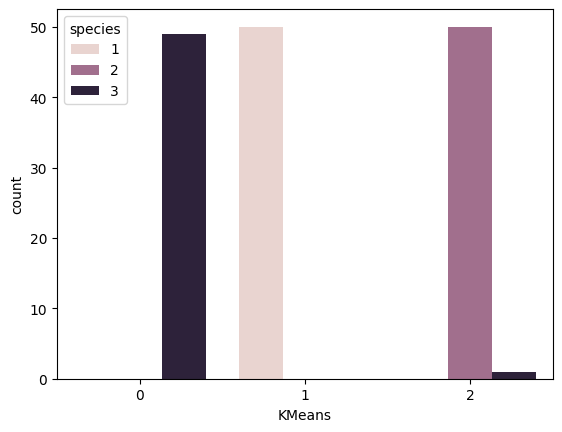

In [174]:
sns.countplot(arquivo,x='KMeans',hue='species')

<Axes: ylabel='count'>

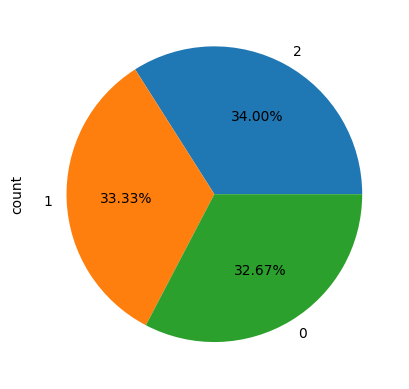

In [175]:
arquivo['KMeans'].value_counts().plot.pie(autopct='%0.2f%%')

<Axes: xlabel='KMeans', ylabel='sepal_length'>

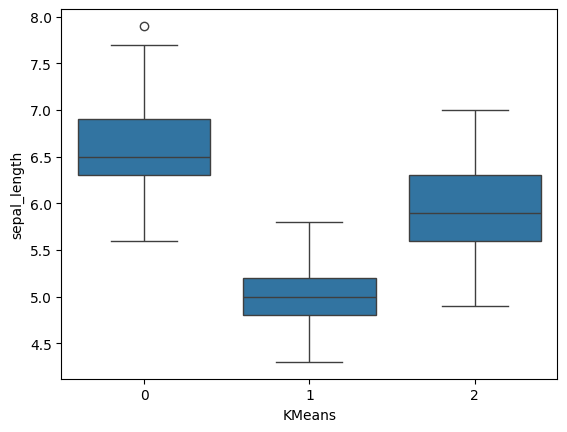

In [176]:
sns.boxplot(data=arquivo,x='KMeans',y='sepal_length')

<Axes: xlabel='KMeans', ylabel='petal_length'>

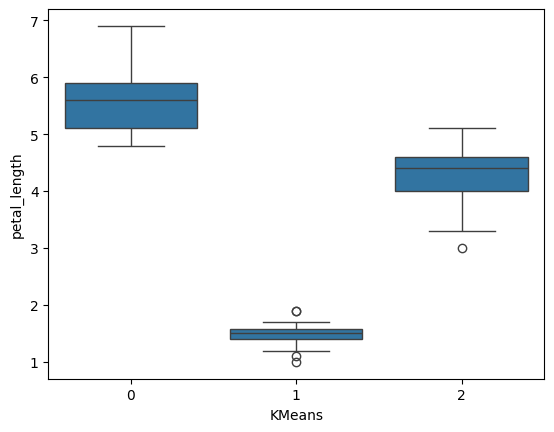

In [177]:
sns.boxplot(data=arquivo,x='KMeans',y='petal_length')